In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                           accuracy_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Generate features
n_samples = 5000
n_features = 10

# Create feature matrix with different distributions
X = pd.DataFrame()

# Numerical features
X['age'] = np.random.normal(45, 15, n_samples).clip(18, 90)
X['income'] = np.random.exponential(50000, n_samples).clip(20000, 200000)
X['years_experience'] = np.random.gamma(2, 5, n_samples).clip(0, 40)
X['credit_score'] = np.random.normal(650, 100, n_samples).clip(300, 850)
X['debt_to_income'] = np.random.beta(2, 5, n_samples) * 0.5
X['num_dependents'] = np.random.poisson(2, n_samples).clip(0, 8)
X['education_years'] = np.random.choice([10, 12, 14, 16, 18, 20], n_samples, 
                                         p=[0.1, 0.2, 0.3, 0.25, 0.1, 0.05])
X['distance_to_work'] = np.random.gamma(2, 5, n_samples).clip(0, 50)
X['previous_defaults'] = np.random.poisson(0.3, n_samples).clip(0, 3)
X['savings_ratio'] = np.random.beta(2, 8, n_samples)

# Add some noise features
X['noise_1'] = np.random.normal(0, 1, n_samples)
X['noise_2'] = np.random.uniform(-2, 2, n_samples)


In [4]:
risk_score = (X['credit_score'] < 580) * 3 + \
             (X['debt_to_income'] > 0.4) * 2 + \
             (X['previous_defaults'] > 0) * 2 + \
             (X['savings_ratio'] < 0.1) * 1.5 + \
             (X['income'] < 30000) * 1

# Add some non-linear interactions
risk_score += (X['debt_to_income'] * X['previous_defaults']) * 2
risk_score += np.where((X['credit_score'] < 600) & (X['debt_to_income'] > 0.5), 2, 0)

# Convert to probability (0-1)
prob_default = 1 / (1 + np.exp(-(risk_score - 3)))  # Logistic function
prob_default = prob_default.clip(0, 1)

# Generate binary labels
y_class = (np.random.random(n_samples) < prob_default).astype(int)

print(f"\nTarget variable (Loan Default) distribution:")
print(f"Default (1): {y_class.sum()} ({y_class.mean()*100:.1f}%)")
print(f"No Default (0): {(len(y_class)-y_class.sum())} ({(1-y_class.mean())*100:.1f}%)")


Target variable (Loan Default) distribution:
Default (1): 1733 (34.7%)
No Default (0): 3267 (65.3%)


In [5]:
# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [9]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

In [10]:
xgb_clf.fit(X_train_clf, y_train_clf,
           eval_set=[(X_test_clf, y_test_clf)],
           verbose=False)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [11]:
# Predictions
y_pred_clf = xgb_clf.predict(X_test_clf)
y_pred_proba = xgb_clf.predict_proba(X_test_clf)[:, 1]

In [12]:
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, 
                           target_names=['No Default', 'Default']))

# ROC-AUC
roc_auc = roc_auc_score(y_test_clf, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

Accuracy: 0.7720

Classification Report:
              precision    recall  f1-score   support

  No Default       0.80      0.86      0.83       653
     Default       0.70      0.60      0.65       347

    accuracy                           0.77      1000
   macro avg       0.75      0.73      0.74      1000
weighted avg       0.77      0.77      0.77      1000

ROC-AUC Score: 0.8207


In [13]:
cv_scores_clf = cross_val_score(xgb_clf, X_train_clf, y_train_clf, 
                                cv=5, scoring='roc_auc')
print(f"\n5-fold Cross-validation ROC-AUC scores: {cv_scores_clf}")


5-fold Cross-validation ROC-AUC scores: [0.86327146 0.87049858 0.86066915 0.83941576 0.83860498]


In [14]:
feature_importance_clf = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

In [15]:
feature_importance_clf.head()

,feature,importance
8,previous_defaults,0.378570
3,credit_score,0.214389
9,savings_ratio,0.068463
1,income,0.060000
10,noise_1,0.038286


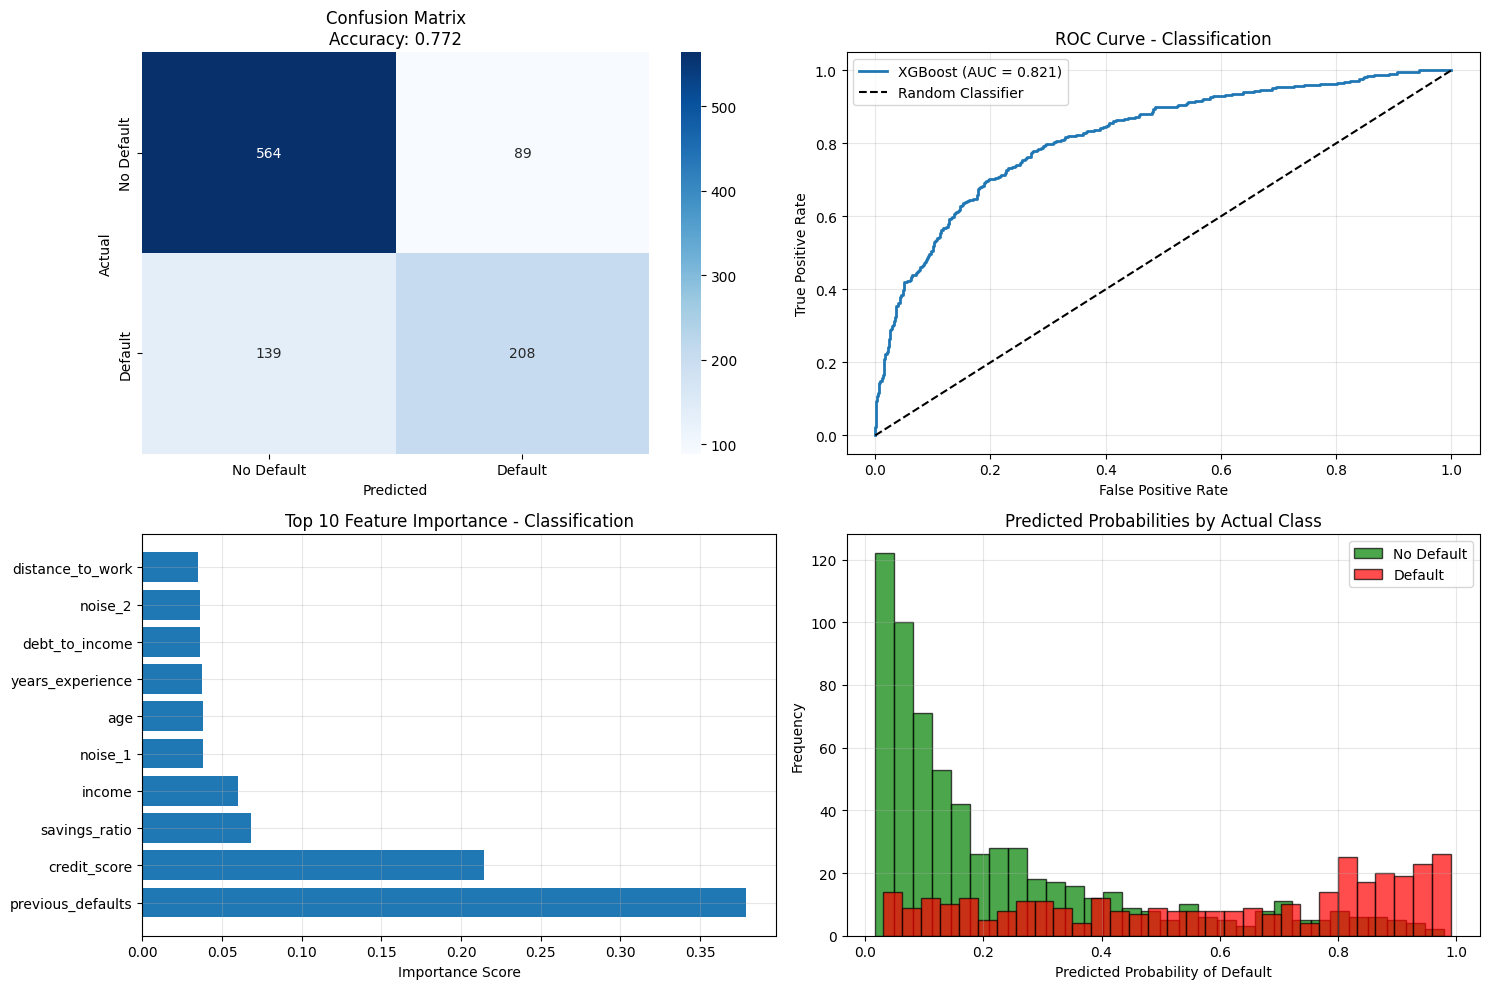

In [16]:
# Visualization for classification
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[0, 0].set_title(f'Confusion Matrix\nAccuracy: {accuracy:.3f}')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_proba)
axes[0, 1].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve - Classification')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
axes[1, 0].barh(feature_importance_clf.head(10)['feature'], 
                feature_importance_clf.head(10)['importance'])
axes[1, 0].set_xlabel('Importance Score')
axes[1, 0].set_title('Top 10 Feature Importance - Classification')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Probability Distribution by Actual Class
axes[1, 1].hist(y_pred_proba[y_test_clf == 0], bins=30, alpha=0.7, 
                label='No Default', color='green', edgecolor='black')
axes[1, 1].hist(y_pred_proba[y_test_clf == 1], bins=30, alpha=0.7, 
                label='Default', color='red', edgecolor='black')
axes[1, 1].set_xlabel('Predicted Probability of Default')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Predicted Probabilities by Actual Class')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()